<a href="https://colab.research.google.com/github/serdararici/btk-datathon-2026/blob/main/notebooks/v1_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Datathon 2026 - V1: EDA & Baseline Model
**Goal:** Predict career_success_score (0-100) | **Metric:** MSE
**Author:** Serdar Arıcı | **Date:** June 2026

In [10]:
# ============================================================
# SECTION 1: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Define the path to your data folder in Drive
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/btk-datathon-2026/'
DATASET_PATH = DATA_PATH + 'datasets/'
OUTPUT_PATH  = DATA_PATH + 'outputs/'

print("Drive mounted successfully!")
print(f"Data path: {DATA_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Data path: /content/drive/MyDrive/Colab Notebooks/btk-datathon-2026/


In [2]:
# ============================================================
# SECTION 2: IMPORTS & SETTINGS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns when printing dataframes
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded!")

Libraries loaded!


In [11]:
# ============================================================
# SECTION 3: LOAD DATA
# ============================================================

train = pd.read_csv(DATASET_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATASET_PATH + 'test_x.csv', encoding='utf-8-sig')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

train.head(3)

Train: (10000, 47)
Test:  (10000, 46)


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.98000,81.77,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.45074,65.54,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.44000,87.18,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...


In [12]:
# ============================================================
# SECTION 4: FIRST LOOK
# ============================================================

# Data types and missing value counts
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       10000 non-null  object 
 1   application_year                 10000 non-null  int64  
 2   age                              10000 non-null  int64  
 3   graduation_year                  10000 non-null  int64  
 4   department                       10000 non-null  object 
 5   university_tier                  10000 non-null  object 
 6   cgpa                             10000 non-null  float64
 7   english_exam_score               9047 non-null   float64
 8   attendance_rate                  10000 non-null  float64
 9   failed_courses_count             10000 non-null  int64  
 10  target_role                      10000 non-null  object 
 11  coding_score                     10000 non-null  float64
 12  problem_solving_sco

                                missing_count  missing_pct
internship_duration_months               1657        16.57
english_exam_score                        953         9.53
github_avg_stars                          910         9.10
open_source_contribution_count            910         9.10
hr_interview_score                        780         7.80
linkedin_profile_score                    668         6.68
portfolio_score                           364         3.64


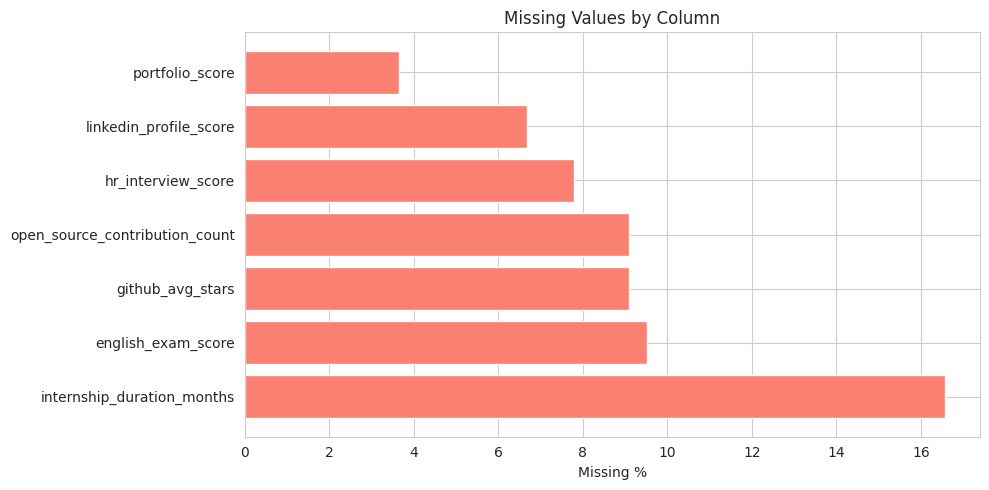

Chart saved to Drive!


In [13]:
# ============================================================
# SECTION 5: MISSING VALUE ANALYSIS
# ============================================================

# Count and percentage of missing values per column
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
print(missing_df)

# Visualize
plt.figure(figsize=(10, 5))
plt.barh(missing_df.index, missing_df['missing_pct'], color='salmon')
plt.xlabel('Missing %')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'missing_values.png', dpi=150)
plt.show()
print("Chart saved to Drive!")

count    10000.000000
mean        76.942507
std         15.186669
min          0.000000
25%         66.937500
50%         77.810000
75%         88.472500
max        100.000000
Name: career_success_score, dtype: float64

Skewness: -0.4507


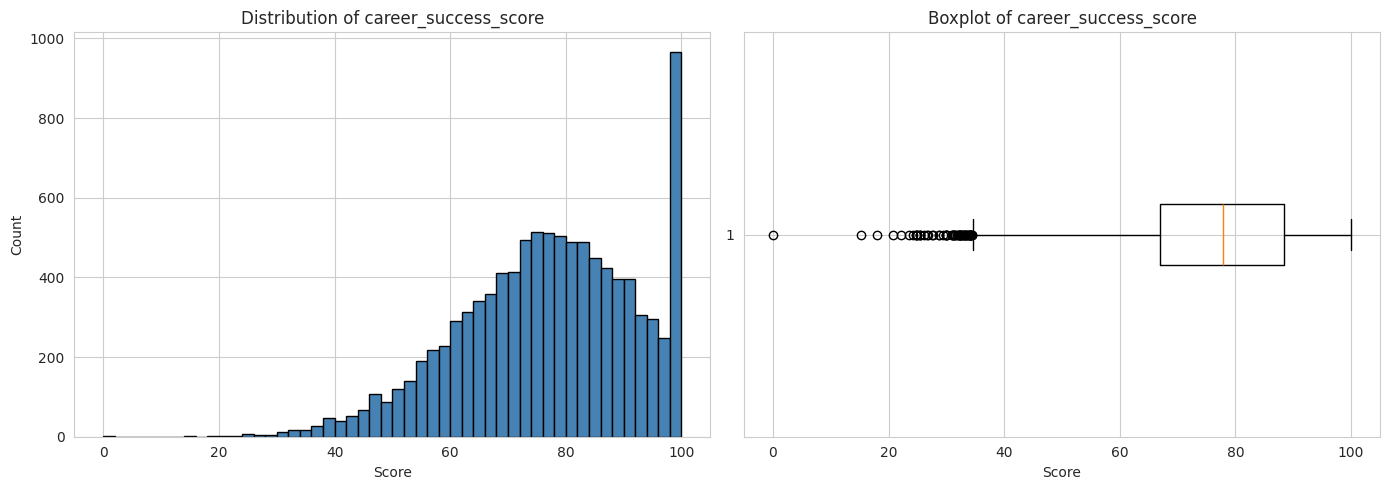

Chart saved to Drive!


In [8]:
# ============================================================
# SECTION 6: TARGET VARIABLE DISTRIBUTION
# ============================================================

target = 'career_success_score'

print(train[target].describe())
print(f"\nSkewness: {train[target].skew():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train[target], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of career_success_score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(train[target], vert=False)
axes[1].set_title('Boxplot of career_success_score')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'target_distribution.png', dpi=150)
plt.show()
print("Chart saved to Drive!")

Top 10 positive correlations:
project_quality_score        0.541063
technical_interview_score    0.340448
problem_solving_score        0.289990
cloud_score                  0.276863
coding_score                 0.274396
devops_score                 0.272033
portfolio_score              0.270772
backend_score                0.266532
real_client_project_count    0.258805
data_structures_score        0.251838
Name: career_success_score, dtype: float64

Bottom 5 negative correlations:
age                    -0.004306
cgpa                   -0.014919
failed_courses_count   -0.059402
graduation_year        -0.060823
application_year       -0.062786
Name: career_success_score, dtype: float64


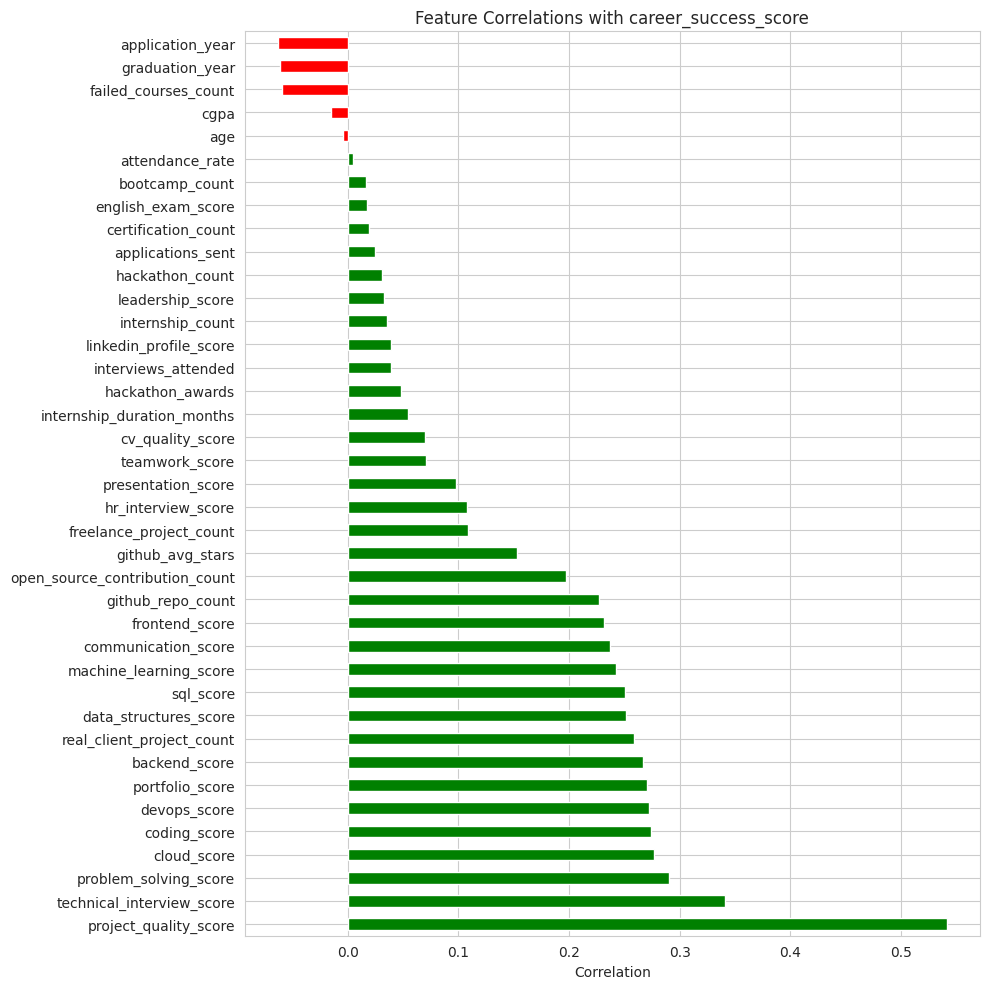

Chart saved to Drive!


In [9]:
# ============================================================
# SECTION 7: CORRELATION ANALYSIS
# ============================================================

# Select only numeric columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Correlation with target, sorted
correlations = train[numeric_cols].corr()[target].drop(target).sort_values(ascending=False)

print("Top 10 positive correlations:")
print(correlations.head(10))
print("\nBottom 5 negative correlations:")
print(correlations.tail(5))

# Visualize
plt.figure(figsize=(10, 10))
colors = ['green' if x > 0 else 'red' for x in correlations]
correlations.plot(kind='barh', color=colors)
plt.title('Feature Correlations with career_success_score')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'correlations.png', dpi=150)
plt.show()
print("Chart saved to Drive!")